# Qiskit

Quantum Launcher is compatible with qiskit backends and features many qiskit-based algorithms.

Let's start by defining a problem to be solved, we will use Exact Cover in this tutorial.

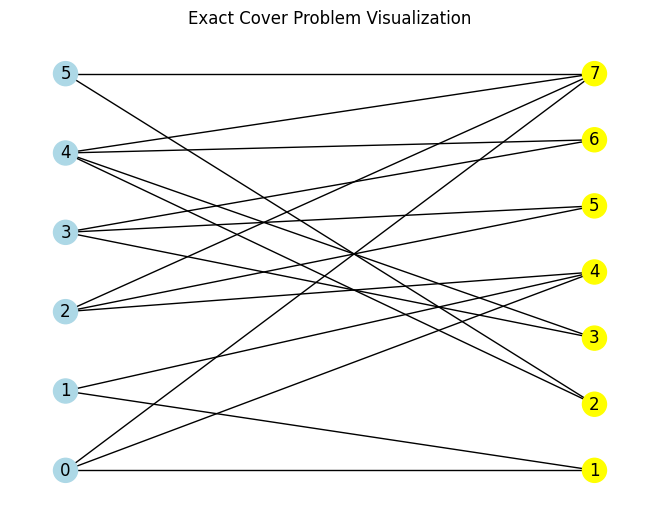

In [1]:
from quantum_launcher.problems import EC

pr = EC.from_preset("toy")
pr.visualize()

## Quantum Approximate Optimization Algorithm

Algorithm we're going to use is Quantum Approximate Optimization Algorithm (QAOA), let's initialize it!

In [2]:
from quantum_launcher.routines.qiskit_routines import QAOA

alg = QAOA()

Now we need to define the backend our algorithm will run on, you can use a local simulator or a real AQT computer if you have access to one.

In [ ]:
from quantum_launcher.routines.qiskit_routines import QiskitBackend, AQTBackend

backend = QiskitBackend('local_simulator')

Now we can use Quantum launcher to launch QAOA on the selected backend.

In [4]:
from quantum_launcher.launcher import QuantumLauncher

launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run(onehot="exact")
result

Result(bitstring=101010, energy=2.7470703125)

Be careful! QAOA returns reversed bitstring!

The results correspond to the following matching:

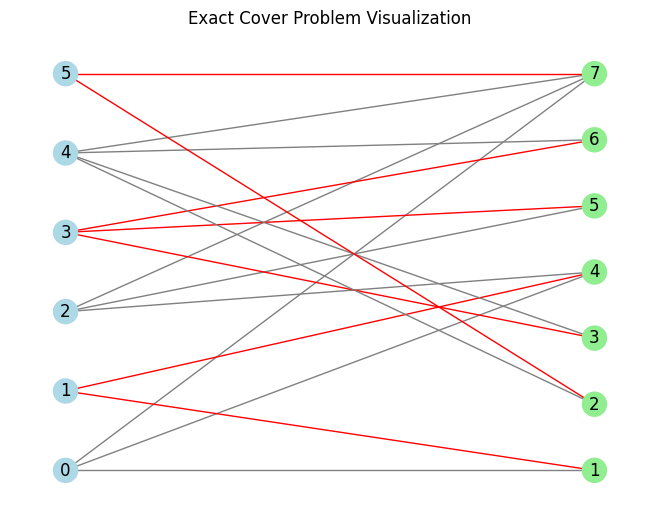

In [5]:
pr.visualize(result.best_bitstring[::-1])

as you can see QAOA solved this problem with flying colors.

Quantum launcher allows you to easily test different combinations of problems, algorithms and backend simply by swapping out the arguments, let's try out the Max Cut Problem:

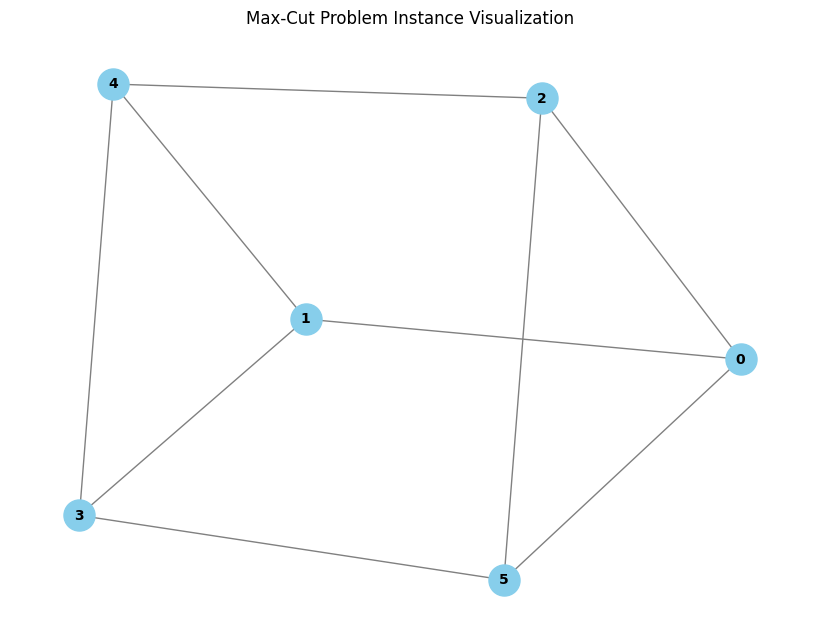

In [6]:
from quantum_launcher.problems import MaxCut

pr = MaxCut.from_preset("default")
pr.visualize()

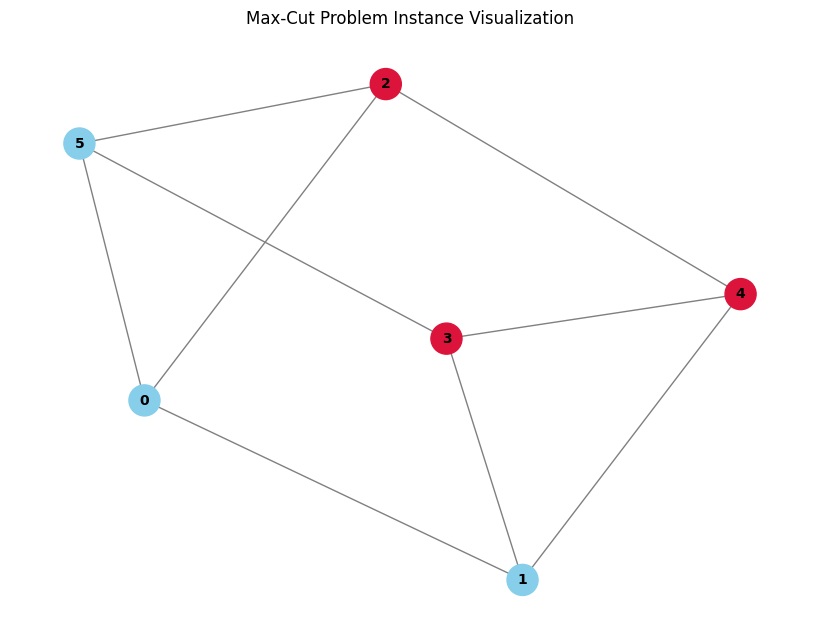

In [7]:
launcher = QuantumLauncher(pr,alg,backend)
result = launcher.run()
pr.visualize(result.best_bitstring)